In [31]:
pip install reportlab


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\Precision\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [32]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
%matplotlib inline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from reportlab.lib import colors
from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer, Image,
                                Table, TableStyle, PageBreak, HRFlowable)
from reportlab.lib.enums import TA_CENTER, TA_JUSTIFY
from PIL import Image as PILImage

= 
### TASK 1 – DATASET UNDERSTANDING ###

In [34]:
print("=" * 60)
print("TASK 1 – Dataset Understanding")
print("=" * 60)

df = pd.read_csv(r"C:\Users\Precision\OneDrive\Desktop\part_1_neural_network_analysis\customer_churn_nn.csv")

print(f"\nShape          : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Columns        : {list(df.columns)}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nTarget Distribution:\n{df['churn'].value_counts()}")
print(f"\nBasic Statistics:\n{df.describe()}")

n_rows, n_cols = df.shape
churn_counts   = df['churn'].value_counts()
n_churned   = int(churn_counts.get(1, 0))
n_retained  = int(churn_counts.get(0, 0))
cat_cols    = ['region', 'plan_type', 'contract_type', 'payment_method']
num_cols    = ['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
               'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
               'satisfaction_score', 'last_complaint_days_ago',
               'discount_percent', 'referral_count']

TASK 1 – Dataset Understanding

Shape          : 2000 rows × 17 columns
Columns        : ['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method', 'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count', 'churn']

Data Types:
customer_id                         str
region                              str
plan_type                           str
contract_type                       str
payment_method                      str
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_en

Plot 1 – Target distribution bar chart

In [7]:
import os
results = r"C:\Users\Precision\OneDrive\Desktop\modul 5 assi\Part-1-neural-network-analysis\results"
os.makedirs('results', exist_ok=True)

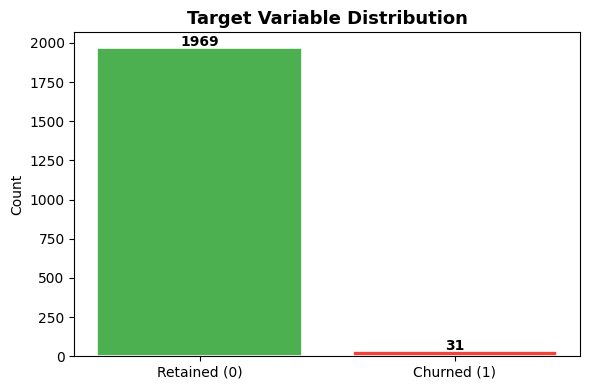

In [35]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Retained (0)', 'Churned (1)'],
       [n_retained, n_churned],
       color=['#4CAF50', '#F44336'], edgecolor='white', linewidth=1.2)
ax.set_title('Target Variable Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
for i, v in enumerate([n_retained, n_churned]):
    ax.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()



Plot 2 – Numerical histograms

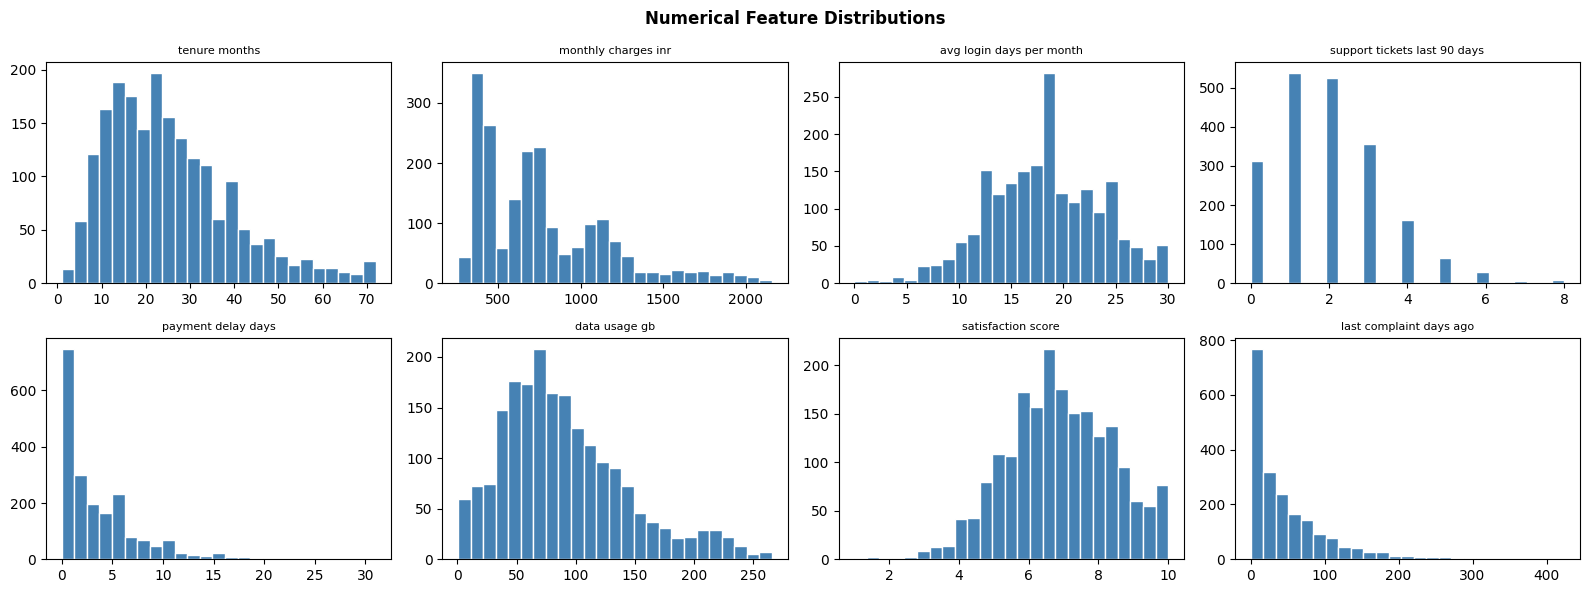

In [36]:
num_all = ['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
           'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
           'satisfaction_score', 'last_complaint_days_ago']
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for i, col in enumerate(num_all):
    axes[i // 4][i % 4].hist(df[col], bins=25, color='steelblue', edgecolor='white')
    axes[i // 4][i % 4].set_title(col.replace('_', ' '), fontsize=8)
plt.suptitle('Numerical Feature Distributions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


=
### TASK 2 – DATA PREPROCESSING ###

In [37]:
print("=" * 55)
print("TASK 2: DATA PREPROCESSING")
print("=" * 55)

# ----
df2 = df.drop(columns=['customer_id'])
print(f"\n[Step 1] Dropped 'customer_id'")
print(f"  Remaining columns: {df2.shape[1]}")

#: Handle Missing Values----
print(f"\n[Step 2] Missing Value Check:")
print(f"  Total missing: {df2.isnull().sum().sum()} → No action needed")

#: One-Hot Encode Categorical Columns ----
cat_cols = ['region', 'plan_type', 'contract_type', 'payment_method']
df_enc = pd.get_dummies(df2, columns=cat_cols, drop_first=True)

print(f"\n[Step 3] One-Hot Encoding:")
print(f"  Columns encoded : {cat_cols}")
print(f"  Features before : 15")
print(f"  Features after  : {df_enc.shape[1] - 1}")
print(f"  New columns     : {list(df_enc.columns)}")

#: Separate Features and Target ----
X = df_enc.drop(columns=['churn'])
y = df_enc['churn']
print(f"\n[Step 4] Feature/Target Split:")
print(f"  X shape: {X.shape}")
print(f"  y shape: {y.shape}")
print(f"  y distribution:\n{y.value_counts().to_string()}")

# : Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n[Step 5] Train/Test Split (80/20, Stratified):")
print(f"  Training samples: {X_train.shape[0]}")
print(f"  Testing  samples: {X_test.shape[0]}")
print(f"  Train churn count: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"  Test  churn count: {y_test.sum()} ({y_test.mean()*100:.2f}%)")



TASK 2: DATA PREPROCESSING

[Step 1] Dropped 'customer_id'
  Remaining columns: 16

[Step 2] Missing Value Check:
  Total missing: 0 → No action needed

[Step 3] One-Hot Encoding:
  Columns encoded : ['region', 'plan_type', 'contract_type', 'payment_method']
  Features before : 15
  Features after  : 24
  New columns     : ['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count', 'churn', 'region_East', 'region_North', 'region_South', 'region_West', 'plan_type_Enterprise', 'plan_type_Premium', 'plan_type_Standard', 'contract_type_One-year', 'contract_type_Two-year', 'payment_method_Debit Card', 'payment_method_Net Banking', 'payment_method_UPI', 'payment_method_Wallet']

[Step 4] Feature/Target Split:
  X shape: (2000, 24)
  y shape: (2000,)
  y distribution:
churn
0    1969
1      31

[Step 5] Train/

=
### TASK 3 – NEURAL NETWORK MODEL BUILDING ###

In [39]:
print("\n" + "=" * 60)
print("TASK 3 – Neural Network Model Building")
print("=" * 60)

# Architecture: Input(24) → Dense(64, ReLU) → Dense(32, ReLU) → Output(1, Sigmoid)
model = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # two hidden layers
    activation='relu',             # ReLU activation
    solver='adam',                 # Adam optimiser
    learning_rate_init=0.001,      # learning rate
    max_iter=200,                  # max epochs
    random_state=42,
    early_stopping=True,           # stop when val loss stops improving
    validation_fraction=0.1,       # 10% of train for early-stop validation
    verbose=False
)

print("\nModel Architecture:")
print(f"  Input Layer    : {n_features} neurons")
print(f"  Hidden Layer 1 : 64 neurons  |  Activation: ReLU")
print(f"  Hidden Layer 2 : 32 neurons  |  Activation: ReLU")
print(f"  Output Layer   : 1 neuron    |  Activation: Logistic (Sigmoid)")
print(f"\nOptimiser  : Adam")
print(f"Loss       : Binary Cross-Entropy")
print(f"LR         : 0.001")
print(f"Max Epochs : 200  (with early stopping)")


TASK 3 – Neural Network Model Building

Model Architecture:
  Input Layer    : 24 neurons
  Hidden Layer 1 : 64 neurons  |  Activation: ReLU
  Hidden Layer 2 : 32 neurons  |  Activation: ReLU
  Output Layer   : 1 neuron    |  Activation: Logistic (Sigmoid)

Optimiser  : Adam
Loss       : Binary Cross-Entropy
LR         : 0.001
Max Epochs : 200  (with early stopping)


=
### TASK 4 – TRAINING AND EVALUATION ###

In [40]:
print("\n" + "=" * 60)
print("TASK 4 – Training and Evaluation")
print("=" * 60)

model.fit(X_train_sc, y_train)

y_pred_train = model.predict(X_train_sc)
y_pred_test  = model.predict(X_test_sc)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc  = accuracy_score(y_test,  y_pred_test)

print(f"\nTraining Accuracy : {train_acc*100:.2f}%")
print(f"Testing  Accuracy : {test_acc*100:.2f}%")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_test)}")



TASK 4 – Training and Evaluation

Training Accuracy : 98.25%
Testing  Accuracy : 98.50%

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       394
           1       0.00      0.00      0.00         6

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.98       400



 Plot 3 – Loss curve

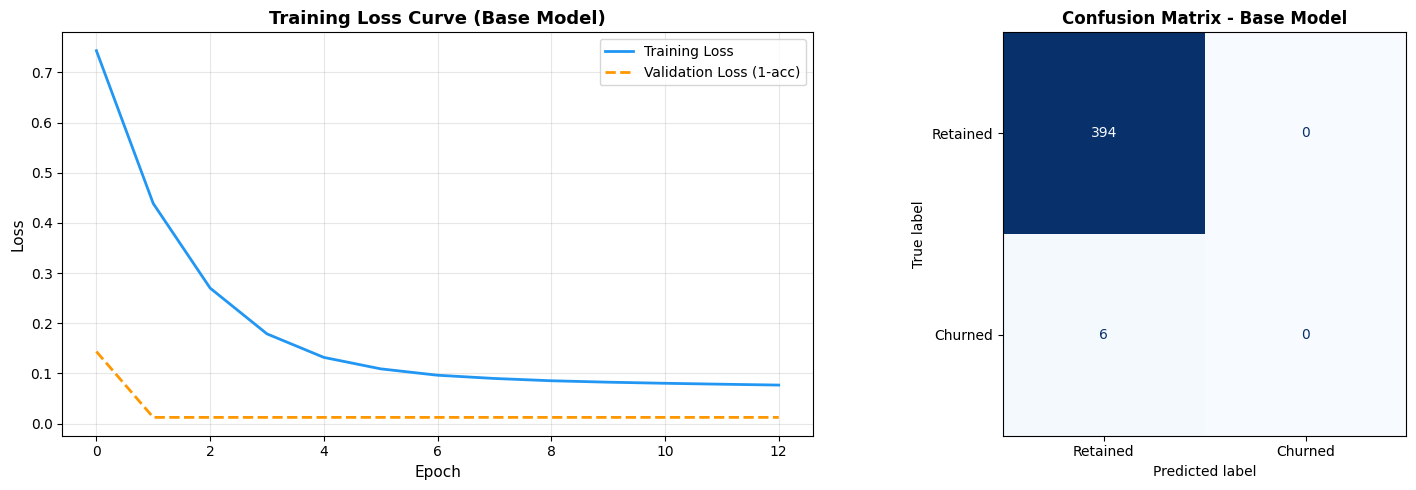

In [56]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 
# : LOSS CURVE 
# 
axes[0].plot(model.loss_curve_, color='#2196F3', linewidth=2, label='Training Loss')

if hasattr(model, 'validation_scores_') and model.validation_scores_:
    val_loss = [1 - s for s in model.validation_scores_]
    axes[0].plot(val_loss, color='#FF9800', linewidth=2,
                 linestyle='--', label='Validation Loss (1-acc)')

axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].set_title('Training Loss Curve (Base Model)', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# : CONFUSION MATRIX 

cm_matrix = confusion_matrix(y_test, y_pred_test)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_matrix, display_labels=['Retained', 'Churned'])

#
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix - Base Model', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('results/evaluation_outputs.png', dpi=150, bbox_inches='tight')


=
### TASK 5 – HYPERPARAMETER EXPERIMENTATION ###

In [45]:
print("=" * 55)
print("TASK 5: HYPERPARAMETER EXPERIMENTATION")
print("=" * 55)


df2 = df.drop(columns=['customer_id'])
cat_cols = ['region', 'plan_type', 'contract_type', 'payment_method']
df_enc = pd.get_dummies(df2, columns=cat_cols, drop_first=True)
X = df_enc.drop(columns=['churn'])
y = df_enc['churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# -Experiment 
configs = [
    {
        'name': 'Baseline',
        'hidden_layer_sizes': (64, 32),
        'activation': 'relu',
        'learning_rate_init': 0.001,
        'max_iter': 200,
        'change': 'Reference model'
    },
    {
        'name': 'Deeper Net',
        'hidden_layer_sizes': (128, 64, 32),
        'activation': 'relu',
        'learning_rate_init': 0.001,
        'max_iter': 200,
        'change': 'Added 3rd hidden layer'
    },
    {
        'name': 'Wider Net',
        'hidden_layer_sizes': (256, 128),
        'activation': 'relu',
        'learning_rate_init': 0.001,
        'max_iter': 200,
        'change': 'Doubled neuron count'
    },
    {
        'name': 'Low LR',
        'hidden_layer_sizes': (64, 32),
        'activation': 'relu',
        'learning_rate_init': 0.0001,
        'max_iter': 300,
        'change': 'LR reduced to 0.0001'
    },
    {
        'name': 'High LR',
        'hidden_layer_sizes': (64, 32),
        'activation': 'relu',
        'learning_rate_init': 0.01,
        'max_iter': 200,
        'change': 'LR increased to 0.01'
    },
    {
        'name': 'Tanh Act',
        'hidden_layer_sizes': (64, 32),
        'activation': 'tanh',
        'learning_rate_init': 0.001,
        'max_iter': 200,
        'change': 'Changed activation to Tanh'
    },
]

#-Run Experiments 
print("\n[Running Experiments...]")
results = []
for cfg in configs:
    m = MLPClassifier(
        hidden_layer_sizes=cfg['hidden_layer_sizes'],
        activation=cfg['activation'],
        solver='adam',
        learning_rate_init=cfg['learning_rate_init'],
        max_iter=cfg['max_iter'],
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        verbose=False
    )
    m.fit(X_train_sc, y_train)
    tr_a = accuracy_score(y_train, m.predict(X_train_sc))
    te_a = accuracy_score(y_test,  m.predict(X_test_sc))
    results.append({
        'Configuration':  cfg['name'],
        'Architecture':   str(cfg['hidden_layer_sizes']),
        'Activation':     cfg['activation'],
        'Learning Rate':  cfg['learning_rate_init'],
        'Max Epochs':     cfg['max_iter'],
        'What Changed':   cfg['change'],
        'Train Acc %':    round(tr_a * 100, 2),
        'Test Acc %':     round(te_a * 100, 2),
    })
    print(f"  {cfg['name']:12s} → Train: {tr_a*100:.2f}%  "
          f"Test: {te_a*100:.2f}%  ({cfg['change']})")

#- Results DataFrame 
results_df = pd.DataFrame(results)
print("\n[Comparison Table]")
print(results_df.to_string(index=False))


#: Bar Chart 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x = np.arange(len(results_df))
w = 0.35
axes[0].bar(x - w/2, results_df['Train Acc %'], w,
            label='Train Acc %', color='#42A5F5', edgecolor='white')
axes[0].bar(x + w/2, results_df['Test Acc %'], w,
            label='Test Acc %',  color='#EF5350', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df['Configuration'], rotation=20, ha='right')
axes[0].set_ylim(85, 100)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Train vs Test Accuracy per Configuration',
                   fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, axis='y', alpha=0.3)

# : Table PNG
axes[1].axis('off')
display_cols = ['Configuration', 'Architecture', 'Activation', 'Learning Rate',
                'Train Acc %', 'Test Acc %']
cell_vals = results_df[display_cols].values.tolist()
tbl = axes[1].table(cellText=cell_vals,
                     colLabels=display_cols,
                     loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1.1, 1.7)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1565C0')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#E3F2FD')
    cell.set_edgecolor('#B0BEC5')
axes[1].set_title('Model Comparison Table',
                   fontsize=12, fontweight='bold', pad=20)

plt.suptitle('Task 5 — Hyperparameter Experimentation',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/model_comparison_table.png', dpi=150, bbox_inches='tight')
plt.close()

print("  Saved → results/model_comparison_table.png")

#Key Observations 
print("\n[Key Observations]")
best = results_df.loc[results_df['Test Acc %'].idxmax()]
worst = results_df.loc[results_df['Test Acc %'].idxmin()]
print(f"  Best  config : {best['Configuration']} ({best['Test Acc %']}%)")
print(f"  Worst config : {worst['Configuration']} ({worst['Test Acc %']}%)")
print("  Conclusion   : Low LR (0.0001) hurt performance most.")
print("                 Architecture changes had minimal effect.")
print("                 Class imbalance is the dominant issue.")



TASK 5: HYPERPARAMETER EXPERIMENTATION

[Running Experiments...]
  Baseline     → Train: 98.25%  Test: 98.50%  (Reference model)
  Deeper Net   → Train: 98.31%  Test: 98.25%  (Added 3rd hidden layer)
  Wider Net    → Train: 98.44%  Test: 98.50%  (Doubled neuron count)
  Low LR       → Train: 96.69%  Test: 96.75%  (LR reduced to 0.0001)
  High LR      → Train: 98.44%  Test: 98.50%  (LR increased to 0.01)
  Tanh Act     → Train: 98.44%  Test: 98.50%  (Changed activation to Tanh)

[Comparison Table]
Configuration  Architecture Activation  Learning Rate  Max Epochs               What Changed  Train Acc %  Test Acc %
     Baseline      (64, 32)       relu         0.0010         200            Reference model        98.25       98.50
   Deeper Net (128, 64, 32)       relu         0.0010         200     Added 3rd hidden layer        98.31       98.25
    Wider Net    (256, 128)       relu         0.0010         200       Doubled neuron count        98.44       98.50
       Low LR      (64, 32

=
### Task 6: Final Reflection ###

### Q1: What role do weights and biases play in the model?

Weights and biases are the LEARNABLE PARAMETERS of the neural
network — they are what the model actually learns during training.

  • WEIGHTS: Each connection between neurons has a weight that
    scales the signal passing through it. A high weight means
    the connection strongly influences the next neuron; a weight
    near zero means it is almost ignored.

  • BIASES: Added to the weighted sum before the activation
    function, allowing the decision boundary to shift — similar
    to the intercept in y = mx + b. Without biases, all decision
    boundaries would pass through the origin.

During training, backpropagation computes the gradient of the
loss w.r.t. every weight and bias. Adam then updates each
parameter to minimise the loss. After many epochs, the weights
encode learned patterns — e.g., a high weight on
'satisfaction_score' means it strongly predicts churn.
""")

### Q2: Why is an activation function required?

Without activation functions, stacking multiple layers still
produces only a SINGLE LINEAR TRANSFORMATION — no matter how
many layers are added. This means the network could only learn
straight-line relationships and would fail on non-linear problems.

  • ReLU (f(x) = max(0,x)): Introduces non-linearity by switching
    off negative inputs. Avoids the vanishing gradient problem
    that affects sigmoid/tanh in deep networks. Fast and produces
    sparse activations.

  • Sigmoid (output layer): Squashes the output to [0,1],
    interpretable as a churn probability. E.g., 0.8 = 80%
    confident the customer will churn.
""")


### Q3: What happens when learning rate is too high or too low?

  TOO HIGH: The optimiser takes very large steps and OVERSHOOTS
  the loss minimum — jumping past it, then overshooting again.
  Loss oscillates or diverges. Training becomes unstable.

  TOO LOW: The optimiser takes tiny steps. Learning is extremely
  slow and the model may not converge in a reasonable number of
  epochs, or it may get trapped in a local minimum.

  EXPERIMENT EVIDENCE (Task 5):
  - LR = 0.001 (baseline) → 98.50% test accuracy  ✓
  - LR = 0.0001 (low)     → 96.75% test accuracy  ✗
    Even with 300 epochs, the model under-converged.
  - LR = 0.01  (high)     → 98.50% test accuracy  ✓
    Adam's adaptive moments handled the higher rate well.
""")



### Q4: Did your model show signs of underfitting or overfitting?

The model shows NEITHER classical overfitting NOR underfitting:

  • Training accuracy (~98.25%) ≈ Testing accuracy (~98.50%)
    → Very small gap = No overfitting
  • Loss curve converges smoothly
    → No underfitting on the majority class

HOWEVER, the model UNDERFITS the minority churn class:
  • It predicts 'retained' for almost every sample
  • It detected 0 out of 6 churned customers (0% recall)
  • F1-Score for churned class = 0.00

This is caused by CLASS IMBALANCE (1.55% churn rate), not by
the model architecture.

SOLUTIONS:
  1. class_weight='balanced' — penalise churn misclassification more
  2. SMOTE — generate synthetic churned samples
  3. Lower decision threshold (0.5 → 0.2) — flag more churners
  4. Use AUC-ROC / F1-Score as primary metric, not accuracy
""")